# Baseline Solution Testing (Fast Version)

This notebook tests simple prediction strategies on the **sample dataset** to establish performance benchmarks quickly.

**Baselines tested:**
1. Last Value Persistence (naive forecast)
2. Moving Average (provided example)
3. Exponential Moving Average (best alpha)

**Note:** Uses sample_train.parquet for faster iteration.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time

# Add competition package to path
sys.path.append('../competition_package')
from utils import DataPoint, ScorerStepByStep

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load Sample Data

In [2]:
# Use sample training data for faster testing
data_path = 'data/sample_train.parquet'
scorer = ScorerStepByStep(data_path)

print(f"Dataset: {len(scorer.dataset):,} rows")
print(f"Features: {scorer.dim}")
print(f"Sequences: {scorer.dataset['seq_ix'].nunique()}")

Dataset: 40,000 rows
Features: 32
Sequences: 40


## 2. Define Baseline Models

In [3]:
class LastValueModel:
    """Predict next value as current value (persistence)."""
    def __init__(self):
        self.current_seq_ix = None
    
    def predict(self, data_point: DataPoint) -> np.ndarray:
        if self.current_seq_ix != data_point.seq_ix:
            self.current_seq_ix = data_point.seq_ix
        
        if not data_point.need_prediction:
            return None
        
        return data_point.state.copy()


class MovingAverageModel:
    """Predict as mean of all previous values in sequence."""
    def __init__(self):
        self.current_seq_ix = None
        self.sequence_history = []
    
    def predict(self, data_point: DataPoint) -> np.ndarray:
        if self.current_seq_ix != data_point.seq_ix:
            self.current_seq_ix = data_point.seq_ix
            self.sequence_history = []
        
        self.sequence_history.append(data_point.state.copy())
        
        if not data_point.need_prediction:
            return None
        
        return np.mean(self.sequence_history, axis=0)


class ExponentialMovingAverageModel:
    """Predict using exponential weighted moving average."""
    def __init__(self, alpha=0.3):
        self.alpha = alpha
        self.current_seq_ix = None
        self.ema = None
    
    def predict(self, data_point: DataPoint) -> np.ndarray:
        if self.current_seq_ix != data_point.seq_ix:
            self.current_seq_ix = data_point.seq_ix
            self.ema = None
        
        if self.ema is None:
            self.ema = data_point.state.copy()
        else:
            self.ema = self.alpha * data_point.state + (1 - self.alpha) * self.ema
        
        if not data_point.need_prediction:
            return None
        
        return self.ema.copy()

## 3. Test Baselines

In [4]:
results = {}

# Test Last Value
print("Testing Last Value Persistence...")
start = time.time()
lv_model = LastValueModel()
lv_results = scorer.score(lv_model)
results['Last Value'] = lv_results['mean_r2']
print(f"  Mean R²: {lv_results['mean_r2']:.6f} ({time.time()-start:.1f}s)\n")

# Test Moving Average
print("Testing Moving Average...")
start = time.time()
ma_model = MovingAverageModel()
ma_results = scorer.score(ma_model)
results['Moving Average'] = ma_results['mean_r2']
print(f"  Mean R²: {ma_results['mean_r2']:.6f} ({time.time()-start:.1f}s)\n")

# Test EMA with different alphas
alphas = [0.1, 0.3, 0.5, 0.7]
ema_scores = {}
for alpha in alphas:
    print(f"Testing EMA (alpha={alpha})...")
    start = time.time()
    ema_model = ExponentialMovingAverageModel(alpha=alpha)
    ema_results = scorer.score(ema_model)
    ema_scores[alpha] = ema_results['mean_r2']
    print(f"  Mean R²: {ema_results['mean_r2']:.6f} ({time.time()-start:.1f}s)")

best_alpha = max(ema_scores, key=ema_scores.get)
results[f'EMA (α={best_alpha})'] = ema_scores[best_alpha]
print(f"\nBest EMA: alpha={best_alpha}, R²={ema_scores[best_alpha]:.6f}")

Testing Last Value Persistence...


  0%|          | 0/40000 [00:00<?, ?it/s]

  Mean R²: -0.427213 (0.1s)

Testing Moving Average...


  0%|          | 0/40000 [00:00<?, ?it/s]

  Mean R²: 0.174067 (2.7s)

Testing EMA (alpha=0.1)...


...

  Mean R²: 0.160488 (0.1s)
Testing EMA (alpha=0.5)...


  0%|          | 0/40000 [00:00<?, ?it/s]

  Mean R²: 0.059877 (0.1s)
Testing EMA (alpha=0.7)...


  0%|          | 0/40000 [00:00<?, ?it/s]

  Mean R²: -0.083900 (0.1s)

Best EMA: alpha=0.1, R²=0.219135


## 4. Baseline Comparison

In [5]:
# Create comparison DataFrame
comparison = pd.DataFrame([
    {'Model': k, 'Mean R²': v} for k, v in results.items()
]).sort_values('Mean R²', ascending=False)

print("\n" + "="*70)
print("BASELINE MODEL COMPARISON (Sample Dataset)")
print("="*70)
print(comparison.to_string(index=False))
print(f"\nBest baseline: {comparison.iloc[0]['Model']}")
print(f"Target R² to beat: {comparison.iloc[0]['Mean R²']:.6f}")


BASELINE MODEL COMPARISON (Sample Dataset)
         Model   Mean R²
   EMA (α=0.1)  0.219135
Moving Average  0.174067
    Last Value -0.427213

Best baseline: EMA (α=0.1)
Target R² to beat: 0.219135


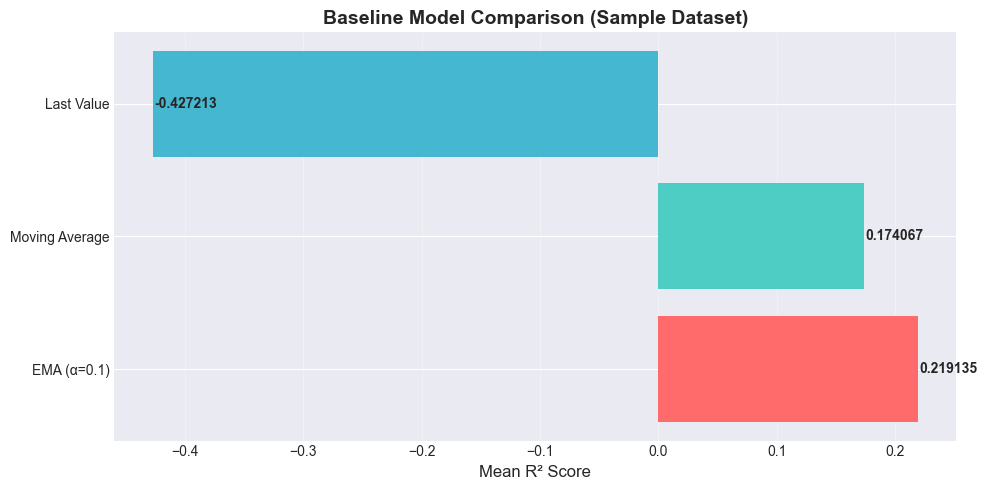

In [6]:
# Visualize
plt.figure(figsize=(10, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.barh(comparison['Model'], comparison['Mean R²'], color=colors)
plt.xlabel('Mean R² Score', fontsize=12)
plt.title('Baseline Model Comparison (Sample Dataset)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(comparison.iterrows()):
    plt.text(row['Mean R²'] + 0.001, i, f"{row['Mean R²']:.6f}", 
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Per-Feature Analysis (Best Model)

In [7]:
# Get best model results
best_model_name = comparison.iloc[0]['Model']

if 'Last Value' in best_model_name:
    best_results = lv_results
elif 'Moving Average' in best_model_name:
    best_results = ma_results
else:  # EMA
    best_model = ExponentialMovingAverageModel(alpha=best_alpha)
    best_results = scorer.score(best_model)

# Extract per-feature scores
feature_scores = [(feat, best_results[feat]) for feat in scorer.features]
feature_scores_df = pd.DataFrame(feature_scores, columns=['Feature', 'R²'])
feature_scores_df = feature_scores_df.sort_values('R²', ascending=False)

print(f"\nPer-Feature Performance ({best_model_name}):")
print(f"\nTop 10 features:")
print(feature_scores_df.head(10).to_string(index=False))

print(f"\nBottom 10 features:")
print(feature_scores_df.tail(10).to_string(index=False))

  0%|          | 0/40000 [00:00<?, ?it/s]


Per-Feature Performance (EMA (α=0.1)):

Top 10 features:
Feature       R²
     14 0.348266
     18 0.316416
     30 0.311584
     13 0.303068
      6 0.302154
     20 0.295501
      7 0.291073
     22 0.281844
      3 0.279058
     27 0.274971

Bottom 10 features:
Feature       R²
     31 0.181851
     10 0.163814
      1 0.159943
     19 0.144007
     12 0.139719
      4 0.137094
     17 0.132042
     29 0.108230
      0 0.106890
     21 0.070902


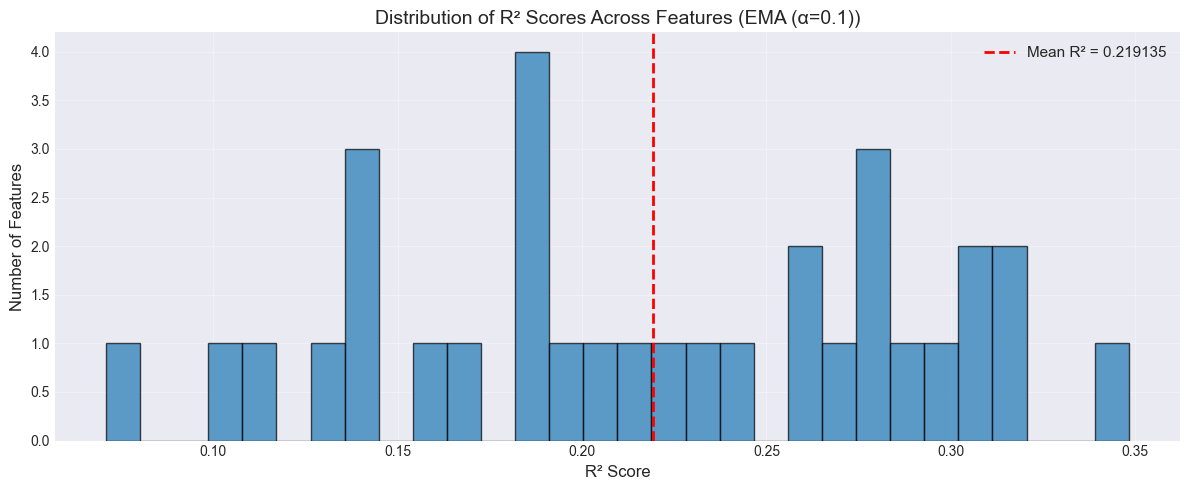

In [8]:
# Distribution of R² scores across features
plt.figure(figsize=(12, 5))
plt.hist(feature_scores_df['R²'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=best_results['mean_r2'], color='red', linestyle='--', 
            linewidth=2, label=f'Mean R² = {best_results["mean_r2"]:.6f}')
plt.xlabel('R² Score', fontsize=12)
plt.ylabel('Number of Features', fontsize=12)
plt.title(f'Distribution of R² Scores Across Features ({best_model_name})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Test on Validation Set

In [9]:
# Load validation data
val_path = 'data/sample_val.parquet'
val_scorer = ScorerStepByStep(val_path)

print(f"Validation dataset: {len(val_scorer.dataset):,} rows")
print(f"Sequences: {val_scorer.dataset['seq_ix'].nunique()}")

# Test best baseline on validation set
print(f"\nTesting {best_model_name} on validation set...")

if 'Last Value' in best_model_name:
    val_model = LastValueModel()
elif 'Moving Average' in best_model_name:
    val_model = MovingAverageModel()
else:  # EMA
    val_model = ExponentialMovingAverageModel(alpha=best_alpha)

val_results = val_scorer.score(val_model)

print(f"\nValidation Results:")
print(f"  Train R²: {best_results['mean_r2']:.6f}")
print(f"  Val R²:   {val_results['mean_r2']:.6f}")
print(f"  Difference: {abs(best_results['mean_r2'] - val_results['mean_r2']):.6f}")

Validation dataset: 10,000 rows
Sequences: 10

Testing EMA (α=0.1) on validation set...


  0%|          | 0/10000 [00:00<?, ?it/s]


Validation Results:
  Train R²: 0.219135
  Val R²:   0.331577
  Difference: 0.112442


## 7. Key Insights

**Summary:**
- Best baseline model and its R² score
- Performance consistency between train/val
- Features that are easy/hard to predict
- Target performance for ML models

**Next Steps:**
- Build LSTM/GRU model to beat baseline
- Focus on features with low R² scores
- Experiment with sequence length and architecture